# Solution: Cluster Iris Flowers with K-Means 🌸

Cluster iris flowers using only **petal length** and **petal width**, decide on scaling, use an elbow plot to pick `k`, and check the clusters against the true species.

## Step 1 — Load the data and keep the petal features

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv('iris.csv')
X = df[['petal_length', 'petal_width']].copy()
df.head()

,sepal_length,sepal_width,petal_length,petal_width,flower
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Step 2 — Look at the data

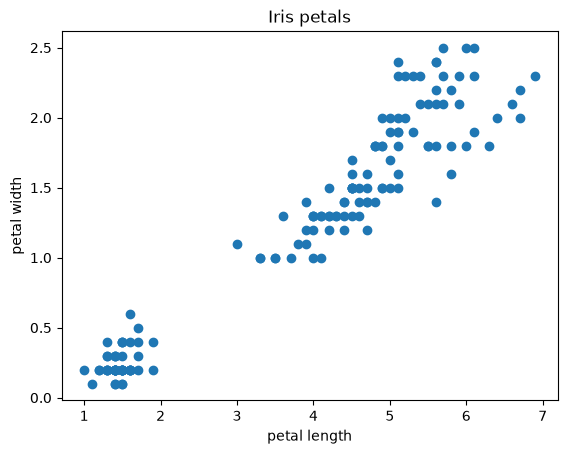

In [2]:
plt.scatter(X['petal_length'], X['petal_width'])
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.title('Iris petals')
plt.show()

There's one tight little group in the bottom-left and a larger spread-out group to the upper-right — so we'd expect roughly **2 or 3** clusters.

## Step 3 — Scale the features

In [3]:
from sklearn.preprocessing import MinMaxScaler

X[['petal_length', 'petal_width']] = MinMaxScaler().fit_transform(X)
X.head()

,petal_length,petal_width
0,0.067797,0.041667
1,0.067797,0.041667
2,0.050847,0.041667
3,0.084746,0.041667
4,0.067797,0.041667


Scaling puts both features on a 0–1 range. Here the effect is **small** — petal length (~1–7 cm) and petal width (~0.1–2.5 cm) were already fairly comparable, so the cluster shapes barely change. It's still good practice, and it matters a lot when features have wildly different units.

## Step 4 — Elbow plot

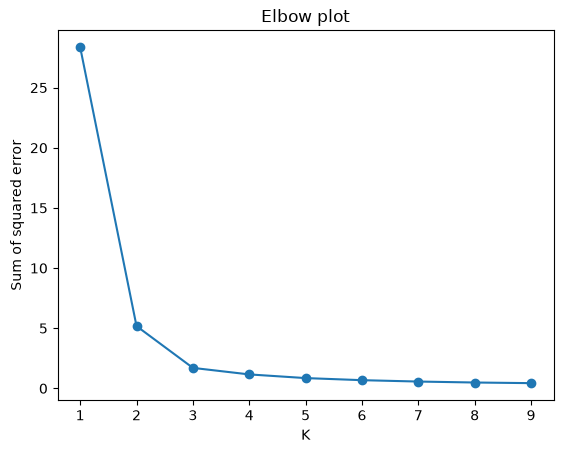

In [4]:
from sklearn.cluster import KMeans

sse = []
k_rng = range(1, 10)
for k in k_rng:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    sse.append(km.inertia_)

plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.title('Elbow plot')
plt.plot(k_rng, sse, 'o-')
plt.show()

The SSE drops steeply up to **k=3** and then flattens out — the elbow is at **k=3**. (That's a nice sanity check, since iris has three species.)

## Step 5 — Cluster with k=3 and visualize

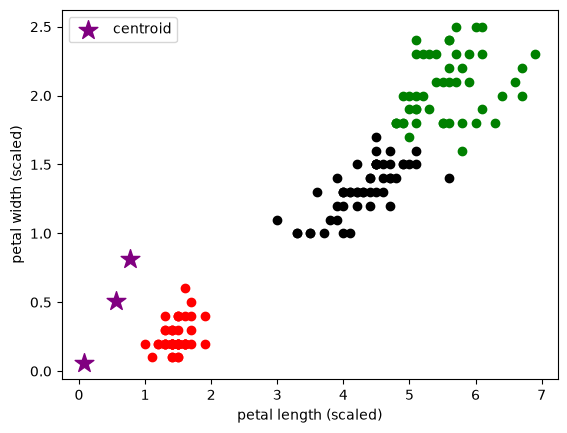

In [5]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X)

df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1['petal_length'], df1['petal_width'], color='green')
plt.scatter(df2['petal_length'], df2['petal_width'], color='red')
plt.scatter(df3['petal_length'], df3['petal_width'], color='black')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            color='purple', marker='*', s=200, label='centroid')
plt.xlabel('petal length (scaled)')
plt.ylabel('petal width (scaled)')
plt.legend()
plt.show()

## Step 6 — How well do the clusters match the real species?

In [6]:
pd.crosstab(df['cluster'], df['flower'])

flower,setosa,versicolor,virginica
cluster,,,
0,0,2,46
1,50,0,0
2,0,48,4


## Conclusions

1. **The elbow plot points to `k = 3`.**
2. **Scaling barely changed anything** here — the two petal features were already on similar scales. (It would matter far more with mixed units, like age vs income in the lecture.)
3. **The clusters line up remarkably well with the true species:** *setosa* is separated perfectly, and *versicolor* / *virginica* are almost perfect with only a handful of borderline flowers mixed up — impressive, considering K-Means never saw the labels. That's the power of unsupervised clustering when the groups are well separated.

> Note: we set `random_state=42` and `n_init=10` on `KMeans` so the results are reproducible. The specific cluster *numbers* (0/1/2) are arbitrary labels — only the grouping matters.